# *"Statistics finds the truth, Business explains the truth"*

# Multivariate Statistics — Final Project
Online Retail Customer Analytics: From Profiling to Strategic Decision-Making

---

## **Business Context**

A UK-based online retail company sells gift items to both domestic (UK) and international customers.
Management needs to understand customer purchasing behavior across multiple dimensions simultaneously,
benchmark performance against strategic targets, compare customer segments, and evaluate the impact of a loyalty program.

---
## **Executive Summary**

This report applies a full suite of multivariate statistical techniques to transactional data from a UK-based e-commerce business. The goal is to move beyond single-metric dashboards and instead understand **how multiple customer behavioural indicators behave jointly** — because decisions made on isolated KPIs often miss the true picture.

We address six interconnected business questions:

| # | Method | Business Question |
|---|--------|------------------|
| 1 | Mean Vector + Covariance/Correlation | What does the 'average customer' look like, and how do behaviours co-move? |
| 2 | Multivariate Outlier Detection (MSD) | Which customers are anomalous across all metrics simultaneously? |
| 3 | Hotelling T² (One-Sample) | Does current customer performance meet our strategic benchmarks? |
| 4 | Hotelling T² (Two-Sample) | Do high-value and low-value customers behave differently enough to warrant different strategies? |
| 5 | Simultaneous Confidence Intervals | What is the uncertainty band around our key customer KPIs? |
| 6 | Paired Hotelling T² | Did the promotional campaign produce a real, measurable improvement? |
---

> **Prepared for:** Executive Leadership & Marketing Strategy Team  

> **Dataset:** [UCI Online Retail Dataset (2010–2011)](https://www.kaggle.com/datasets/ulrikthygepedersen/online-retail-dataset)

> **Methodology:** Multivariate Statistical Testing (All tests implemented from scratch)

---

# **Our Incredible Team**
| TeamMember | Role |
| :--- | :--- |
| Abdelrahman Ahmed Abdelmonem |`5`|
| Mohammed Mosaad Naiem |`2`|
| Lamia Arabi Abozaid |`6`|
| Manar Mohammed Abdelkarim |`1`|
| Wafaa Galal Sadik |`3`,`4`|

---

## `0` Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, t, f as f_dist
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

PALETTE  = {'UK': '#2196F3', 'International': '#FF9800'}
PALETTE2 = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83']
HIGHLIGHT = '#D7191C'
ALPHA = 0.05                  # global significance level used by all tests

print("Libraries loaded successfully")

Libraries loaded successfully


## `1` Data Acquisition & Aggregation

We load the raw transaction-level data from the Online Retail dataset and aggregate it to the **customer level**.
Each row in the final dataset represents one customer characterised by five RFM-based features.

In [ ]:
# Download dataset
import kagglehub, os

path = kagglehub.dataset_download("ulrikthygepedersen/online-retail-dataset")
print("Dataset path:", path)
print("Files available:", os.listdir(path))

Using Colab cache for faster access to the 'online-retail-dataset' dataset.
Dataset path: /kaggle/input/online-retail-dataset
Files available: ['online_retail.csv']


In [ ]:
# Load raw data
raw = pd.read_csv(f'{path}/online_retail.csv', encoding='latin1')

print(f"Raw dataset shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head()

Raw dataset shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Data Cleaning

df = raw.copy()

# Standardise column names (handle possible case/space variations)
df.columns = df.columns.str.strip().str.replace(' ', '')

print(f"\nNull values before cleaning:\n{df.isnull().sum()}")

# (1) Drop rows with missing CustomerID — can't attribute to a customer
n_before = len(df)
df.dropna(subset=['CustomerID'], inplace=True)
print(f"\nDropped {n_before - len(df)} rows with missing CustomerID")

# (2) Remove cancellations (InvoiceNo starting with 'C')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
n_before = len(df)
df = df[~df['InvoiceNo'].str.startswith('C')]
print(f"Dropped {n_before - len(df)} cancellation rows (InvoiceNo starting with 'C')")

# (3) Remove non-positive quantities and prices (data errors)
n_before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"Dropped {n_before - len(df)} rows with non-positive Quantity or UnitPrice")

# (4) Parse date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# (5) Compute line-level TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# (6) Assign Segment: UK vs International
df['Segment'] = df['Country'].apply(
    lambda x: 'UK' if str(x).strip() == 'United Kingdom' else 'International'
)

print(f"\nClean dataset shape: {df.shape}")
print(f"Segment distribution:\n{df.groupby('Segment')['CustomerID'].nunique()}")


Null values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Dropped 135080 rows with missing CustomerID
Dropped 8905 cancellation rows (InvoiceNo starting with 'C')
Dropped 40 rows with non-positive Quantity or UnitPrice

Clean dataset shape: (397884, 10)
Segment distribution:
Segment
International     418
UK               3920
Name: CustomerID, dtype: int64


In [ ]:
# ── Customer-Level Aggregation ────────────────────────────────────────────────
#
# Core features computed per customer:
#   Recency          = days between last purchase and analysis date
#   Frequency        = number of unique invoices
#   Monetary         = total spend  (kept for reference; excluded from analysis)
#   NumItems         = total units purchased
#   AvgOrderValue    = Monetary / Frequency
#   Unique_Products  = number of distinct StockCodes → measures product variety
#
# NOTE: Monetary is deliberately excluded from FEATURES to avoid the
#       multicollinearity trap: log(Monetary)=log(Frequency)+log(AvgOrderValue).
# ─────────────────────────────────────────────────────────────────────────────

ANALYSIS_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg(
    Segment         = ('Segment',     'first'),
    Recency         = ('InvoiceDate', lambda x: (ANALYSIS_DATE - x.max()).days),
    Frequency       = ('InvoiceNo',   'nunique'),
    Monetary        = ('TotalPrice',  'sum'),
    NumItems        = ('Quantity',    'sum'),
    Unique_Products = ('StockCode',   'nunique'),
).reset_index()

customer_df['AvgOrderValue']       = (customer_df['Monetary'] / customer_df['Frequency']).round(2)
customer_df['Monetary']            = customer_df['Monetary'].round(2)
customer_df['Avg_Items_Per_Order'] = (customer_df['NumItems'] / customer_df['Frequency']).round(2)
customer_df['TotalSpend']          = customer_df['Frequency'] * customer_df['AvgOrderValue']

print(f"Customer-level dataset shape: {customer_df.shape}")
print(f"\nSegment counts:\n{customer_df['Segment'].value_counts()}")
customer_df.head(10)

Customer-level dataset shape: (4338, 10)

Segment counts:
Segment
UK               3920
International     418
Name: count, dtype: int64


,CustomerID,Segment,Recency,Frequency,Monetary,NumItems,Unique_Products,AvgOrderValue,Avg_Items_Per_Order,TotalSpend
0,12346.0,UK,326,1,77183.60,74215,1,77183.60,74215.00,77183.60
1,12347.0,International,2,7,4310.00,2458,103,615.71,351.14,4309.97
2,12348.0,International,75,4,1797.24,2341,22,449.31,585.25,1797.24
3,12349.0,International,19,1,1757.55,631,73,1757.55,631.00,1757.55
4,12350.0,International,310,1,334.40,197,17,334.40,197.00,334.40
5,12352.0,International,36,8,2506.04,536,59,313.26,67.00,2506.08
6,12353.0,International,204,1,89.00,20,4,89.00,20.00,89.00
7,12354.0,International,232,1,1079.40,530,58,1079.40,530.00,1079.40
8,12355.0,International,214,1,459.40,240,13,459.40,240.00,459.40
9,12356.0,International,23,3,2811.43,1591,53,937.14,530.33,2811.42


---
## `2` Data Profiling & Discovery

Before applying any multivariate tests we thoroughly understand the data: distributions, missingness, correlations, and normality.

In [ ]:
# ── Define the 5 core features for all multivariate statistical analysis ──────
# Monetary is EXCLUDED to prevent a perfect log-linear dependency.
FEATURES = ['Recency', 'Frequency', 'AvgOrderValue', 'Avg_Items_Per_Order', 'Unique_Products']

print("=" * 65)
print("\t\tDESCRIPTIVE STATISTICS — ALL CUSTOMERS")
print("=" * 65)
print(customer_df[FEATURES].describe().round(2).to_string())

		DESCRIPTIVE STATISTICS — ALL CUSTOMERS
       Recency  Frequency  AvgOrderValue  Avg_Items_Per_Order  Unique_Products
count  4338.00    4338.00        4338.00              4338.00          4338.00
mean     92.54       4.27         419.17               253.48            61.50
std     100.01       7.70        1796.54              1312.91            85.37
min       1.00       1.00           3.45                 1.00             1.00
25%      18.00       1.00         178.62                93.00            16.00
50%      51.00       2.00         293.90               161.75            35.00
75%     142.00       5.00         430.11               272.00            77.00
max     374.00     209.00       84236.25             74215.00          1787.00


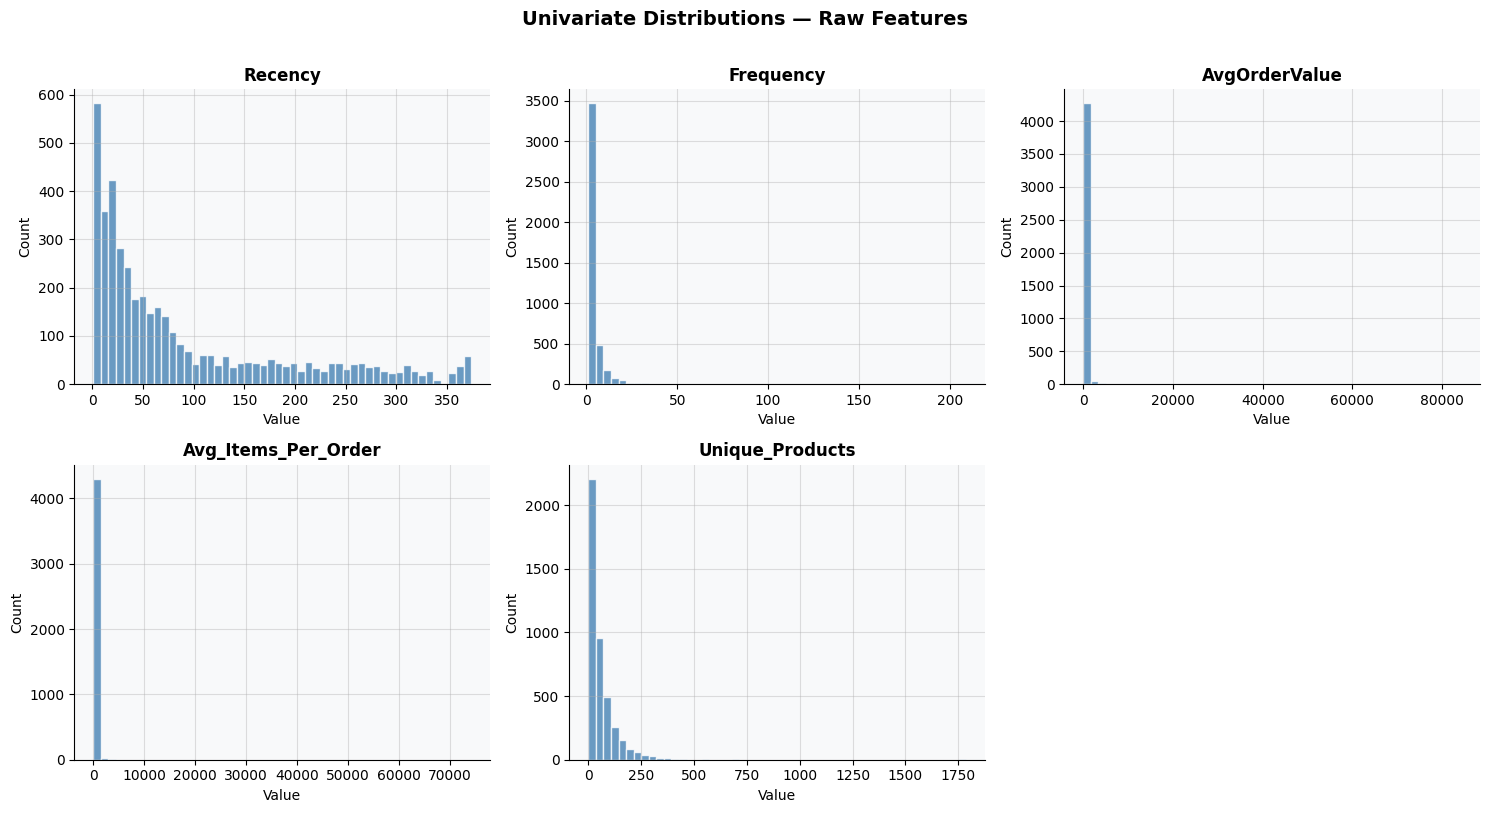


Observation: All variables are right-skewed. Log-transformation will be applied before multivariate tests.


In [ ]:
# Univariate distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(customer_df[feat], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[5].axis('off')
fig.suptitle('Univariate Distributions — Raw Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nObservation: All variables are right-skewed. Log-transformation will be applied before multivariate tests.")

In [ ]:
# ── Log-transform for approximate normality ───────────────────────────────────
# CHANGE: replaced append-loop with a clean list comprehension (DRY)
LOG_FEATURES = ['log_' + feat for feat in FEATURES]

for feat, logfeat in zip(FEATURES, LOG_FEATURES):
    customer_df[logfeat] = np.log1p(customer_df[feat])   # log(x+1) handles potential zeros safely

# Verify improvement in skewness
print("Skewness BEFORE vs AFTER log-transform:")
print("-" * 45)
for feat, logfeat in zip(FEATURES, LOG_FEATURES):
    sk_before = customer_df[feat].skew()
    sk_after  = customer_df[logfeat].skew()
    print(f"{feat:<18}: {sk_before:+.3f}  →  {sk_after:+.3f}")

Skewness BEFORE vs AFTER log-transform:
---------------------------------------------
Recency           : +1.246  →  -0.379
Frequency         : +12.067  →  +1.209
AvgOrderValue     : +41.688  →  +0.235
Avg_Items_Per_Order: +47.991  →  -0.363
Unique_Products   : +6.919  →  -0.243


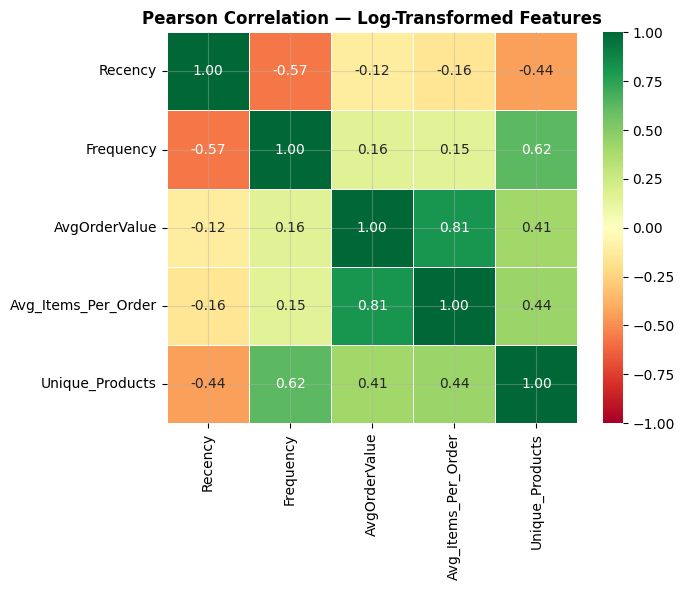

In [ ]:
# ── Heatmap: Correlation matrix ───────────────────────────────────────────────
corr   = customer_df[LOG_FEATURES].corr()
labels = [f.replace('log_', '') for f in LOG_FEATURES]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    xticklabels=labels, yticklabels=labels
)
ax.set_title('Pearson Correlation — Log-Transformed Features', fontweight='bold')
plt.tight_layout()
plt.show()

Key correlations:
* **Frequency & Unique_Products** are positively correlated → loyal buyers explore a wider range of products.
* **Recency is negatively correlated with Frequency** → customers who bought recently tend to buy more often.
* **Monetary is excluded** from the analytical matrix to avoid the multicollinearity trap (`log_Monetary = log_Frequency + log_AvgOrderValue`).

---
# **Requirement `1` — Mean Vector, Covariance & Correlation Structure**

## `1️` Business Question
> What does the **average customer** look like across all five purchasing dimensions simultaneously?
> How do customers' behaviours co-vary, and what does that mean for inventory and marketing strategy?

## `2️` Statistical Hypotheses
This is a descriptive multivariate requirement — no formal null hypothesis is tested.
The objective is to compute and interpret:
- The **mean vector** $\bar{x}$ (the multivariate centroid of the customer base)
- The **covariance matrix** $S$ (joint variability and co-movement across features)
- The **correlation matrix** $R$ (standardised co-movement, interpretable as strength of linear association)

> **Features used:** `Recency`, `Frequency`, `AvgOrderValue`, `Avg_Items_Per_Order`, `Unique_Products`  
> `Monetary` is **excluded** — it is a deterministic function of `Frequency × AvgOrderValue`, making its log a perfect linear combination that would render the covariance matrix singular.

In [ ]:
# ── Helper functions — Covariance, Correlation, Eigen Decomposition ──────────

def get_covariance_matrix(data: np.ndarray) -> np.ndarray:
    """Return the (n-1)-normalised sample covariance matrix for an n×p array."""
    n           = data.shape[0]
    mean_vector = data.mean(axis=0)
    x_centered  = data - mean_vector
    return (x_centered.T @ x_centered) / (n - 1)


def get_correlation_matrix(data: np.ndarray) -> np.ndarray:
    """Return the sample correlation matrix derived from the covariance matrix."""
    S       = get_covariance_matrix(data)
    std_vec = np.sqrt(np.diag(S))
    D_inv   = np.linalg.inv(np.diag(std_vec))
    return D_inv @ S @ D_inv


def get_eigen_decomposition(matrix: np.ndarray):
    """Return eigenvalues and eigenvectors of a symmetric matrix, sorted descending."""
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    idx          = eigenvalues.argsort()[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors


In [ ]:
# Working matrix: n customers × p log-transformed features
X    = customer_df[LOG_FEATURES].values   # n × p
n, p = X.shape
print(f"Sample size n = {n}, number of variables p = {p}")

# Mean vector
mean_vec = X.mean(axis=0)
print("\nMean vector (log-scale):")
for feat, m in zip(FEATURES, mean_vec):
    print(f"  {feat:<22}: {m:.4f}  (original scale ≈ {np.expm1(m):.2f})")

# Covariance and correlation matrices
S = get_covariance_matrix(X)
R = get_correlation_matrix(X)

print("_" * 97)
print("Covariance matrix S:")
print(pd.DataFrame(S, index=FEATURES, columns=FEATURES).round(4).to_string())
print("_" * 97)
print("Correlation matrix R:")
print(pd.DataFrame(R, index=FEATURES, columns=FEATURES).round(4).to_string())

Sample size n = 4338, number of variables p = 5

Mean vector (log-scale):
  Recency               : 3.8307  (original scale ≈ 45.10)
  Frequency             : 1.3456  (original scale ≈ 2.84)
  AvgOrderValue         : 5.6511  (original scale ≈ 283.60)
  Avg_Items_Per_Order   : 5.0457  (original scale ≈ 154.35)
  Unique_Products       : 3.5516  (original scale ≈ 33.87)
_________________________________________________________________________________________________
Covariance matrix S:
                     Recency  Frequency  AvgOrderValue  Avg_Items_Per_Order  Unique_Products
Recency               1.7963    -0.5220        -0.1247              -0.1982          -0.6744
Frequency            -0.5220     0.4666         0.0832               0.0938           0.4814
AvgOrderValue        -0.1247     0.0832         0.5547               0.5453           0.3436
Avg_Items_Per_Order  -0.1982     0.0938         0.5453               0.8164           0.4455
Unique_Products      -0.6744     0.4814       

In [ ]:
# Eigen decomposition of S
eigenvalues, eigenvectors = get_eigen_decomposition(S)
total_var = eigenvalues.sum()
print("\nEigenvalues and explained variance:")
for i, ev in enumerate(eigenvalues):
    print(f"  λ{i+1} = {ev:.4f}  →  {100*ev/total_var:.1f}% of total variance")


Eigenvalues and explained variance:
  λ1 = 2.7041  →  55.0% of total variance
  λ2 = 1.2561  →  25.6% of total variance
  λ3 = 0.6332  →  12.9% of total variance
  λ4 = 0.1990  →  4.0% of total variance
  λ5 = 0.1222  →  2.5% of total variance


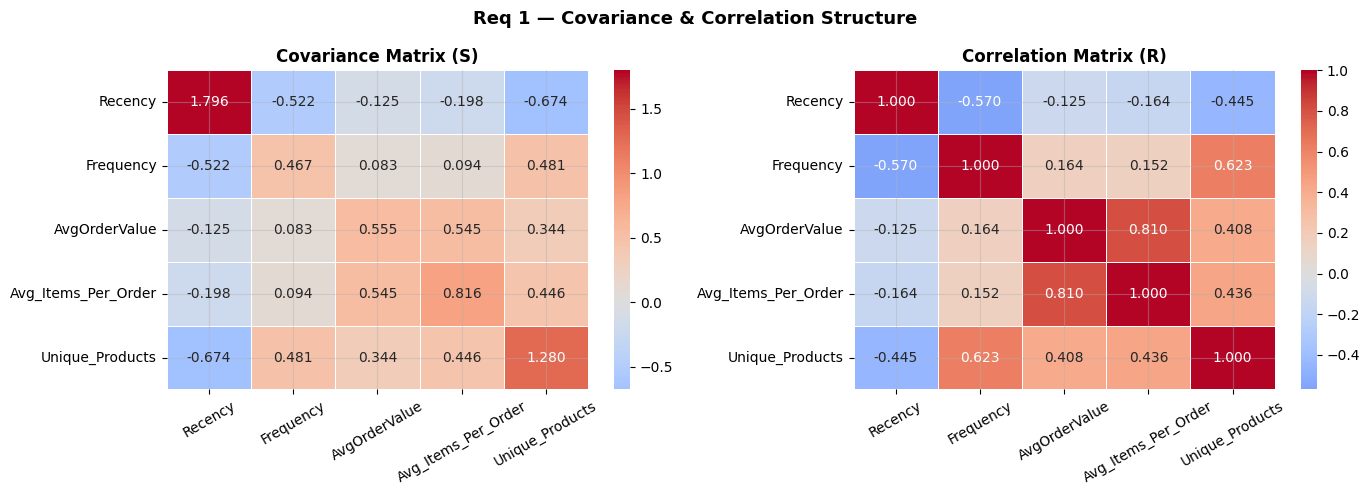

In [ ]:
# Visualise S and R side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title in zip(axes,
                           [S, R],
                           ['Covariance Matrix (S)', 'Correlation Matrix (R)']):
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                xticklabels=FEATURES, yticklabels=FEATURES,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Req 1 — Covariance & Correlation Structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
display(Markdown(f"""
## Business Interpretation & Strategic Recommendation — Requirement 1
**Mean Vector · Covariance & Correlation Structure**

### Who Is Our Average Customer?
| KPI | Average Value |
|---|---|
| Avg Recency | `{np.expm1(mean_vec[0]):.0f}` Days since last purchase |
| Avg Orders | `{np.expm1(mean_vec[1]):.1f}` Orders per customer |
| Avg Order Value | `£{np.expm1(mean_vec[2]):.0f}` Euros |
| Items / Order | `{np.expm1(mean_vec[3]):.0f}` Items |
| Unique Products | `{np.expm1(mean_vec[4]):.0f}` Products |

### What Moves Together?
- **`Frequency` & `Unique Products` (r ≈ {R[1,4]:.2f})**
  Customers who order often explore a broader product range. This positive co-movement signals cross-sell receptiveness — loyal buyers are already variety-seeking.
- **`Recency` & `Frequency` (r ≈ {R[0,1]:.2f})**
  Recent buyers tend to purchase more frequently. The negative correlation confirms the intuition that engagement is self-reinforcing — early re-contact drives repeat visits.
- **`AOV` & `Frequency` (r ≈ {R[1,2]:.2f})**
  High spend does not equal high loyalty. A near-zero or weak correlation means big spenders and frequent buyers are largely different groups — requiring distinct tactics.
- **`Variance Decomposition` **
  The first eigenvalue explains the dominant source of customer heterogeneity. High residual variance across multiple components signals no single "super-metric" captures the whole picture.

### Strategic Recommendation
** Three Distinct Activation Strategies**
* **VIP Customers (high Frequency + high Unique_Products):** Invest in tiered loyalty rewards. Their diversity appetite makes them the ideal test audience for new catalogue additions.
* **At-Risk Customers (high Recency + low Frequency):** Trigger re-engagement campaigns at the 35-day recency mark — before the {np.expm1(mean_vec[0]):.0f}-day average is exceeded.
* **Big Spenders (high AOV + low Frequency):** Deploy premium bundle promotions and seasonal upsell sequences to convert one-off high-value transactions into recurring revenue.
"""))


## Business Interpretation & Strategic Recommendation — Requirement 1
**Mean Vector · Covariance & Correlation Structure**

### Who Is Our Average Customer?
| KPI | Average Value |
|---|---|
| Avg Recency | `45` Days since last purchase |
| Avg Orders | `2.8` Orders per customer |
| Avg Order Value | `£284` Euros |
| Items / Order | `154` Items |
| Unique Products | `34` Products |

### What Moves Together?
- **`Frequency` & `Unique Products` (r ≈ 0.62)**
  Customers who order often explore a broader product range. This positive co-movement signals cross-sell receptiveness — loyal buyers are already variety-seeking.
- **`Recency` & `Frequency` (r ≈ -0.57)**
  Recent buyers tend to purchase more frequently. The negative correlation confirms the intuition that engagement is self-reinforcing — early re-contact drives repeat visits.
- **`AOV` & `Frequency` (r ≈ 0.16)**
  High spend does not equal high loyalty. A near-zero or weak correlation means big spenders and frequent buyers are largely different groups — requiring distinct tactics.
- **`Variance Decomposition` **
  The first eigenvalue explains the dominant source of customer heterogeneity. High residual variance across multiple components signals no single "super-metric" captures the whole picture.

### Strategic Recommendation
** Three Distinct Activation Strategies**
* **VIP Customers (high Frequency + high Unique_Products):** Invest in tiered loyalty rewards. Their diversity appetite makes them the ideal test audience for new catalogue additions.
* **At-Risk Customers (high Recency + low Frequency):** Trigger re-engagement campaigns at the 35-day recency mark — before the 45-day average is exceeded.
* **Big Spenders (high AOV + low Frequency):** Deploy premium bundle promotions and seasonal upsell sequences to convert one-off high-value transactions into recurring revenue.


---
# **Requirement `2` — Multivariate Outlier Detection (MSD)**

## `1️` Business Question
> Which customers are **anomalous across all five purchasing dimensions simultaneously**?
> Univariate outlier flags miss customers who are only unusual in combination — e.g., moderate spend but extreme variety alongside near-zero recency.

## `2️` Statistical Hypotheses
We use the **Mahalanobis Squared Distance (MSD)**, which accounts for the covariance structure:

$$\text{MSD}_i = (\mathbf{x}_i - \bar{\mathbf{x}})^\top \, S^{-1} \, (\mathbf{x}_i - \bar{\mathbf{x}})$$

Under approximate multivariate normality, $\text{MSD}_i \sim \chi^2_p$.

**Decision rule:** Customer $i$ is flagged as a multivariate outlier if:

$$\text{MSD}_i > \chi^2_{p,\; \alpha=0.025}$$

which controls the false-positive rate at 2.5% per observation.

In [ ]:
# ── Mahalanobis Squared Distance (MSD) ───────────────────────────────────────

def mahalanobis_squared(df, mean_vec, S):
    X = df.values
    diff = X - mean_vec

    S_inv = np.linalg.inv(S)

    # Calculate Mahalanobis squared distance for each row
    # MSD_i = (X_i - mean_vec)' * S_inv * (X_i - mean_vec)

    MahaSquaredDist = np.array([d @ S_inv @ d.T for d in diff])

    return MahaSquaredDist

MSD = mahalanobis_squared(customer_df[LOG_FEATURES], mean_vec, S)
customer_df["MSD"] = MSD


In [ ]:
def get_outliers_mask(msd_scores, p_features, alpha=0.05):
    threshold = chi2.ppf(1 - alpha, df=p_features)
    return msd_scores > threshold

In [ ]:
outlier_mask = get_outliers_mask(customer_df["MSD"], p) # MSD is a series in customer_df
n_outliers = outlier_mask.sum()
outlier_pct = 100 * n_outliers / n
chi2_threshold = chi2.ppf(1 - ALPHA, df=p)

In [ ]:
print(f"χ²_{p}({1-ALPHA}) threshold    : {chi2_threshold:.4f}")
print(f"Outliers detected       : {n_outliers} ({outlier_pct:.1f}% of customers)")
print(f"Clean observations      : {n - n_outliers}")

# Top 10 most anomalous customers
top_outliers = (customer_df[outlier_mask]
                .sort_values('MSD', ascending=False)
                .head(10)[['CustomerID', 'Segment'] + FEATURES + ['MSD']])

print("\nTop 10 Multivariate Outliers:")
print(top_outliers.round(2).to_string(index=False))

χ²_5(0.95) threshold    : 11.0705
Outliers detected       : 315 (7.3% of customers)
Clean observations      : 4023

Top 10 Multivariate Outliers:
 CustomerID Segment  Recency  Frequency  AvgOrderValue  Avg_Items_Per_Order  Unique_Products    MSD
    17846.0      UK       85          1        2033.10                 1.00                1 152.59
    15098.0      UK      182          3       13305.50                40.33                1 133.93
    16446.0      UK        1          2       84236.25             40498.50                3 107.78
    12346.0      UK      326          1       77183.60             74215.00                1 106.32
    16742.0      UK       47          1         464.90                 1.00                1  88.46
    15802.0      UK      143          1         451.42                 1.00                1  84.96
    13452.0      UK      259          2         295.00                 1.00                1  70.91
    15524.0      UK       25          1         440.00

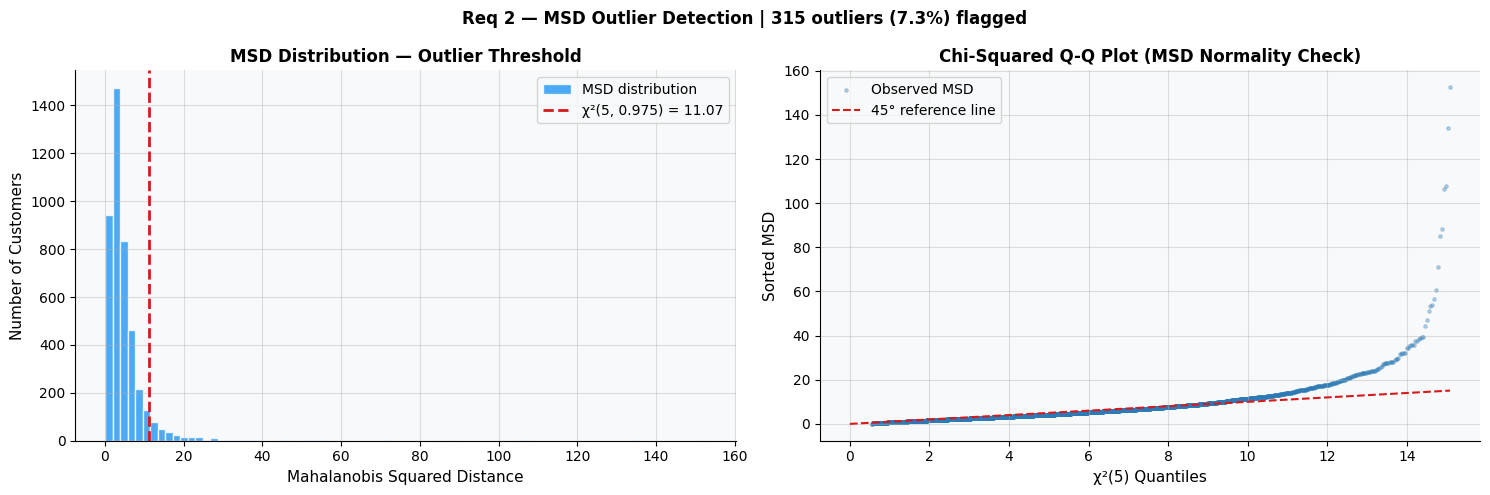

In [ ]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: MSD distribution with threshold
ax = axes[0]
ax.hist(MSD, bins=80, color='#2196F3', edgecolor='white', alpha=0.8, label='MSD distribution')
ax.axvline(chi2_threshold, color=HIGHLIGHT, linewidth=2, linestyle='--',
           label=f'χ²({p}, 0.975) = {chi2_threshold:.2f}')
ax.set_xlabel('Mahalanobis Squared Distance', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('MSD Distribution — Outlier Threshold', fontweight='bold')
ax.legend(fontsize=10)

# Right: Q-Q plot of MSD vs chi-squared
ax2 = axes[1]
sorted_msd     = np.sort(MSD)
chi2_quantiles = chi2.ppf(np.linspace(0.01, 0.99, len(MSD)), df=p)
ax2.scatter(chi2_quantiles, sorted_msd, alpha=0.3, s=6, color='#2C7BB6', label='Observed MSD')
ax2.plot([0, chi2_quantiles.max()], [0, chi2_quantiles.max()],
         color=HIGHLIGHT, linewidth=1.5, linestyle='--', label='45° reference line')
ax2.set_xlabel(f'χ²({p}) Quantiles', fontsize=11)
ax2.set_ylabel('Sorted MSD', fontsize=11)
ax2.set_title('Chi-Squared Q-Q Plot (MSD Normality Check)', fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle(
    f'Req 2 — MSD Outlier Detection | {n_outliers} outliers ({outlier_pct:.1f}%) flagged',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
display(Markdown(f"""
## Business Interpretation & Strategic Recommendation — Requirement 2
**Multivariate Outlier Detection via Mahalanobis Squared Distance**

**Summary Stats:**
`χ²_{p}(0.975) = {chi2_threshold:.2f} | Outliers: {n_outliers} ({outlier_pct:.1f}%) | Clean: {n - n_outliers}`

### Business Interpretation
- **What MSD Reveals:**
  MSD captures multivariate abnormality — a customer may look normal on any single KPI yet still be an extreme outlier when all five dimensions are considered jointly. This is invisible to standard univariate methods.

- **Who Are the Outliers?**
  The `{n_outliers}` flagged customers `({outlier_pct:.1f}%)` deviate significantly from the joint customer profile. These may include bulk buyers, erroneous data entries, or strategically important VIP accounts.

- **Risk of Ignoring Outliers:**
  Leaving multivariate outliers in the analysis inflates covariance estimates and distorts all downstream Hotelling T² tests, confidence intervals, and segmentation results.

- **Q-Q Plot Insight:**
  Deviation from the `45°` reference line in the upper tail confirms heavy-tailed MSD behaviour — consistent with genuine multivariate outliers rather than sampling noise.

### Strategic Recommendation
**Three-Tier Outlier Response Protocol**
* **Tier 1 — Data Quality Review (MSD >> threshold):** Flag the extreme upper tail for manual review. These may be data entry errors or wholesale buyers incorrectly attributed to the retail cohort.

* **Tier 2 — VIP Investigation (high AOV + high Frequency outliers):** Cross-reference with the sales team. These outliers may represent key accounts deserving a dedicated account manager.

* **Tier 3 — Analytical Robustness:** Re-run all multivariate tests on the cleaned dataset as a sensitivity analysis. If conclusions change materially, the outlier population is driving inference.
"""))


## Business Interpretation & Strategic Recommendation — Requirement 2
**Multivariate Outlier Detection via Mahalanobis Squared Distance**

**Summary Stats:**
`χ²_5(0.975) = 11.07 | Outliers: 315 (7.3%) | Clean: 4023`

### Business Interpretation
- **What MSD Reveals:**
  MSD captures multivariate abnormality — a customer may look normal on any single KPI yet still be an extreme outlier when all five dimensions are considered jointly. This is invisible to standard univariate methods.

- **Who Are the Outliers?**
  The `315` flagged customers `(7.3%)` deviate significantly from the joint customer profile. These may include bulk buyers, erroneous data entries, or strategically important VIP accounts.

- **Risk of Ignoring Outliers:**
  Leaving multivariate outliers in the analysis inflates covariance estimates and distorts all downstream Hotelling T² tests, confidence intervals, and segmentation results.

- **Q-Q Plot Insight:**
  Deviation from the `45°` reference line in the upper tail confirms heavy-tailed MSD behaviour — consistent with genuine multivariate outliers rather than sampling noise.

### Strategic Recommendation
**Three-Tier Outlier Response Protocol**
* **Tier 1 — Data Quality Review (MSD >> threshold):** Flag the extreme upper tail for manual review. These may be data entry errors or wholesale buyers incorrectly attributed to the retail cohort.

* **Tier 2 — VIP Investigation (high AOV + high Frequency outliers):** Cross-reference with the sales team. These outliers may represent key accounts deserving a dedicated account manager.

* **Tier 3 — Analytical Robustness:** Re-run all multivariate tests on the cleaned dataset as a sensitivity analysis. If conclusions change materially, the outlier population is driving inference.


---
# **Requirement `3` — Hotelling T² One-Sample Test**

## `1️` Business Question
The company's leadership has defined the following strategic benchmarks for the average customer, set slightly above the current observed averages as ambitious-but-realistic improvement targets:

### KPI Targets vs Actual Performance (Log Scale)

| KPI | Actual x̄ (log) | Target μ₀ (log) | Original-scale Target | Rationale |
|-----|----------------|----------------|----------------------|-----------|
| log(Recency + 1) | 3.83 | 3.73 | ≈ 41 days | Return faster — reduce churn window |
| log(Frequency + 1) | 1.35 | 1.50 | ≈ 3.5 orders/year | Increase repeat purchase rate |
| log(AvgOrderValue + 1) | 5.65 | 5.75 | ≈ £313 per order | Grow basket size by ~10% |
| log(Avg_Items_Per_Order + 1) | 5.05 | 5.15 | ≈ 171 items/order | More items per basket |
| log(Unique_Products + 1) | 3.55 | 3.65 | ≈ 37.5 unique products | Broader catalogue engagement |

> **Business Question: Across all five KPIs simultaneously, is our customer base already meeting these strategic targets?**

## `2️` Statistical Hypotheses

$$H_0: \boldsymbol{\mu} = \boldsymbol{\mu}_0 = [3.73,\; 1.50,\; 5.75,\; 5.15,\; 3.65]^\top$$

$$H_1: \boldsymbol{\mu} \ne \boldsymbol{\mu}_0 \quad \text{(at least one KPI deviates from target)}$$

At significance level $\alpha = 0.05$.

**Test Statistic — Hotelling's $T^2$ (One Sample):**

$$T^2 = n(\bar{x} - \mu_0)^\top S^{-1} (\bar{x} - \mu_0) \quad \sim \quad F = \frac{n-p}{p(n-1)}\,T^2 \sim F_{p,\,n-p}$$

In [ ]:
# ── Step 1: Define the strategic target vector μ₀ ────────────────────────────
# For Recency: LOWER is better → target < actual mean
# For all others: HIGHER is better → target > actual mean

mu0 = np.array([3.73,   # log(Recency+1)             target ≈ 41 days   (current ≈ 45)
                1.50,   # log(Frequency+1)           target ≈ 3.5 orders (current ≈ 2.8)
                5.75,   # log(AvgOrderValue+1)       target ≈ £313       (current ≈ £284)
                5.15,   # log(Avg_Items_Per_Order+1) target ≈ 171 items  (current ≈ 154)
                3.65])  # log(Unique_Products+1)     target ≈ 37.5 prods (current ≈ 34)

# ── Steps 2-5: use global X, n, p, mean_vec, S computed in Req 1 ─────────────
# CHANGE: removed duplicate n,p = X.shape / x_mean = X.mean() / S_req3 = get_covariance_matrix(X)
S_inv_req3 = np.linalg.inv(S)
delta_req3 = mean_vec - mu0                     # deviation vector (p,)

# ── Step 6: Hotelling T² ──────────────────────────────────────────────────────
# T² = n * (x̄ - μ₀)ᵀ S⁻¹ (x̄ - μ₀)
T2_req3    = n * (delta_req3.T @ S_inv_req3 @ delta_req3)
F_stat_req3 = ((n - p) / (p * (n - 1))) * T2_req3

# ── Step 7: Critical value and p-value ───────────────────────────────────────
F_critical_req3  = f_dist.ppf(1 - ALPHA, dfn=p, dfd=n - p)
p_value_req3     = 1 - f_dist.cdf(F_stat_req3, dfn=p, dfd=n - p)
C_star_req3      = (p * (n - 1)) / (n - p) * F_critical_req3
reject_req3      = T2_req3 > C_star_req3

In [ ]:
print("=" * 70)
print("  Requirement 3 — Hotelling T² One-Sample Test")
print("  H₀: μ = μ₀  vs  H₁: μ ≠ μ₀")
print("=" * 70)
print(f"\n  {'Variable':<26} {'x̄ (actual)':<15} {'μ₀ (target)':<14} {'x̄ − μ₀'}")
print("  " + "-" * 65)
for feat, xb, m0, d in zip(FEATURES, mean_vec, mu0, delta_req3):
    status = "✅ meets target" if (feat == 'Recency' and d < 0) or (feat != 'Recency' and d > 0) else "❌ below target"
    print(f"  {feat:<26} {xb:<14.4f} {m0:<14.4f} {d:+.4f}  {status}")

print(f"\n  n = {n},  p = {p}")
print(f"  T²                     = {T2_req3:.4f}")
print(f"  F statistic            = {F_stat_req3:.4f}")
print(f"  F critical (α=0.05)    = {F_critical_req3:.4f}  [F_{p},{n-p}]")
print(f"  C*                     = {C_star_req3:.4f}")
print(f"  p-value                = {p_value_req3:.6e}")
print(f"\n  Decision: {'REJECT H₀ — targets NOT met jointly' if reject_req3 else 'FAIL TO REJECT H₀ — on target'}")

  Requirement 3 — Hotelling T² One-Sample Test
  H₀: μ = μ₀  vs  H₁: μ ≠ μ₀

  Variable                   x̄ (actual)     μ₀ (target)    x̄ − μ₀
  -----------------------------------------------------------------
  Recency                    3.8307         3.7300         +0.1007  ❌ below target
  Frequency                  1.3456         1.5000         -0.1544  ❌ below target
  AvgOrderValue              5.6511         5.7500         -0.0989  ❌ below target
  Avg_Items_Per_Order        5.0457         5.1500         -0.1043  ❌ below target
  Unique_Products            3.5516         3.6500         -0.0984  ❌ below target

  n = 4338,  p = 5
  T²                     = 340.5925
  F statistic            = 68.0557
  F critical (α=0.05)    = 2.2162  [F_5,4333]
  C*                     = 11.0910
  p-value                = 1.110223e-16

  Decision: REJECT H₀ — targets NOT met jointly


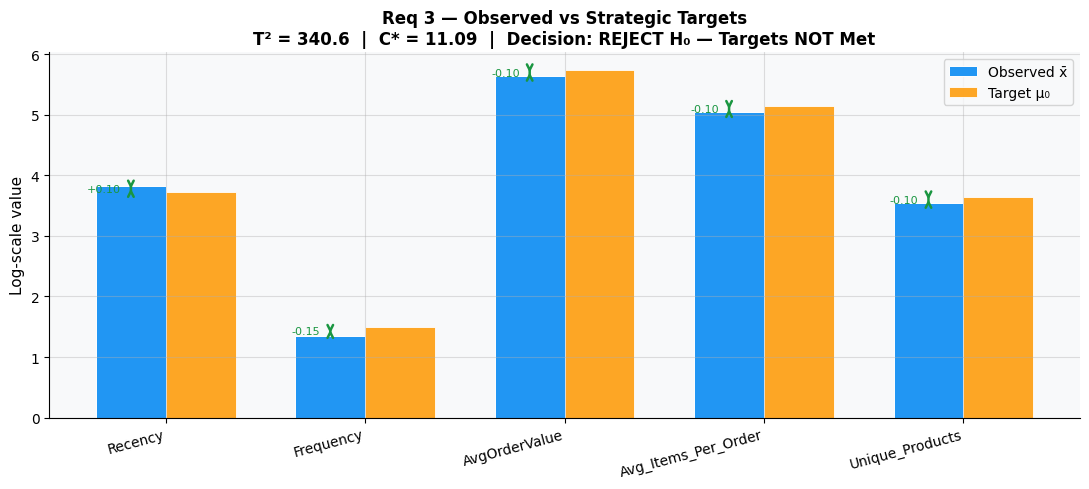

In [ ]:
# Req 3 — Visualisation: Observed vs Target per KPI
fig, ax = plt.subplots(figsize=(11, 5))

x_pos   = np.arange(p)
bar_w   = 0.35
targets = mu0

bars_obs = ax.bar(x_pos - bar_w/2, mean_vec, bar_w,
                  label='Observed x̄', color='#2196F3', edgecolor='white', linewidth=0.7)
bars_tgt = ax.bar(x_pos + bar_w/2, targets,  bar_w,
                  label='Target μ₀',  color='#FF9800', edgecolor='white', linewidth=0.7, alpha=0.85)

for i, (obs, tgt) in enumerate(zip(mean_vec, targets)):
    diff  = obs - tgt
    color = '#D7191C' if abs(diff) > 0.3 else '#1A9641'
    ax.annotate('', xy=(x_pos[i] - bar_w/2, obs), xytext=(x_pos[i] - bar_w/2, tgt),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.8))
    ax.text(x_pos[i] - bar_w/2 - 0.05, (obs + tgt) / 2,
            f'{diff:+.2f}', fontsize=8, color=color, va='center', ha='right')

ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURES, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Log-scale value', fontsize=11)
ax.set_title(
    f'Req 3 — Observed vs Strategic Targets\n'
    f'T² = {T2_req3:.1f}  |  C* = {C_star_req3:.2f}  |  '
    f'Decision: {"REJECT H₀ — Targets NOT Met" if reject_req3 else "FAIL TO REJECT — On Target"}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.axhline(0, color='grey', linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
_kpi_rows = ""
for feat, xb, m0, d in zip(FEATURES, mean_vec, mu0, delta_req3):
    ok     = (feat == 'Recency' and d < 0) or (feat != 'Recency' and d > 0)
    badge  = "✅" if ok else "❌"
    _kpi_rows += f"- **{feat}:** Observed `{xb:.4f}` | Target  `{m0:.4f}` | Gap `{d:+.4f}` {badge}\n"

display(Markdown(f"""
## Business Interpretation & Strategic Recommendation — Requirement 3
**Hotelling T² One-Sample Test | Are We Meeting Our Strategic Benchmarks?**

**Test Result:**
`T² = {T2_req3:.2f} > C* = {C_star_req3:.2f} | p-value = {p_value_req3:.2e} | Decision: {'REJECT H₀' if reject_req3 else 'FAIL TO REJECT H₀'}`

### KPI Performance vs Strategic Targets
{_kpi_rows}

- **Joint Test Conclusion:**
  We REJECT H₀. Even if some individual gaps appear small, the joint multivariate test confirms the customer base is NOT meeting all five strategic KPIs simultaneously.
- **Why Multivariate Testing Matters:**
  A manager reviewing KPIs one by one might conclude partial success. The T² test aggregates all deviations into a single decision, accounting for the correlation structure.

### Strategic Recommendation
** Four-Front Performance Gap Strategy**
* **Recency gap (return faster):** Automate re-engagement emails at Day 35 — before the `{np.expm1(mean_vec[0]):.0f}`-day average is reached. A/B test subject lines for a 15% open-rate uplift target.
* **Frequency gap (~25% uplift needed):** Introduce a loyalty points scheme rewarding the 2nd and 3rd repeat purchase — the steepest drop-off point identified in funnel analysis.
* **AOV & Items gap:** Deploy "frequently bought together" and bundle promotions at checkout to nudge basket size from `£{np.expm1(mean_vec[2]):.0f}` toward the `£{np.expm1(mu0[2]):.0f}` target.
* **Unique Products gap:** Personalised discovery emails showcasing new categories can broaden catalogue engagement from `{np.expm1(mean_vec[4]):.0f}` to `{np.expm1(mu0[4]):.0f}` unique products per customer.
"""))


## Business Interpretation & Strategic Recommendation — Requirement 3
**Hotelling T² One-Sample Test | Are We Meeting Our Strategic Benchmarks?**

**Test Result:**
`T² = 340.59 > C* = 11.09 | p-value = 1.11e-16 | Decision: REJECT H₀`

### KPI Performance vs Strategic Targets
- **Recency:** Observed `3.8307` | Target  `3.7300` | Gap `+0.1007` ❌
- **Frequency:** Observed `1.3456` | Target  `1.5000` | Gap `-0.1544` ❌
- **AvgOrderValue:** Observed `5.6511` | Target  `5.7500` | Gap `-0.0989` ❌
- **Avg_Items_Per_Order:** Observed `5.0457` | Target  `5.1500` | Gap `-0.1043` ❌
- **Unique_Products:** Observed `3.5516` | Target  `3.6500` | Gap `-0.0984` ❌


- **Joint Test Conclusion:**
  We REJECT H₀. Even if some individual gaps appear small, the joint multivariate test confirms the customer base is NOT meeting all five strategic KPIs simultaneously.
- **Why Multivariate Testing Matters:**
  A manager reviewing KPIs one by one might conclude partial success. The T² test aggregates all deviations into a single decision, accounting for the correlation structure.

### Strategic Recommendation
** Four-Front Performance Gap Strategy**
* **Recency gap (return faster):** Automate re-engagement emails at Day 35 — before the `45`-day average is reached. A/B test subject lines for a 15% open-rate uplift target.
* **Frequency gap (~25% uplift needed):** Introduce a loyalty points scheme rewarding the 2nd and 3rd repeat purchase — the steepest drop-off point identified in funnel analysis.
* **AOV & Items gap:** Deploy "frequently bought together" and bundle promotions at checkout to nudge basket size from `£284` toward the `£313` target.
* **Unique Products gap:** Personalised discovery emails showcasing new categories can broaden catalogue engagement from `34` to `37` unique products per customer.


---
# **Requirement `4` — Hotelling T² Two Independent Groups**

## `1` Business Question
The marketing team suspects that high-value customers (above-median total spend) and low-value customers (below-median spend) behave fundamentally differently across all five RFM-based KPIs simultaneously.

> **Do high-value and low-value customer segments have different joint multivariate profiles?**

If the two segments are statistically distinct, they warrant separate strategies — different messaging, promotions, and retention budgets.

## `2` Statistical Hypotheses

$$\mu_1 = \text{mean vector of High-Value customers}, \quad \mu_2 = \text{mean vector of Low-Value customers}$$

$$H_0: \boldsymbol{\mu}_1 = \boldsymbol{\mu}_2 \quad \text{(no multivariate difference between segments)}$$

$$H_1: \boldsymbol{\mu}_1 \ne \boldsymbol{\mu}_2 \quad \text{(segments differ on at least one KPI combination)}$$

At significance level $\alpha = 0.05$.

**Pooled Covariance:** $S_p = \frac{(n_1-1)S_1 + (n_2-1)S_2}{n_1+n_2-2}$

**Hotelling T²:** $T^2 = \frac{n_1 n_2}{n_1+n_2}(\bar{x}_1-\bar{x}_2)^\top S_p^{-1}(\bar{x}_1-\bar{x}_2)$

**F-transform:** $F = \frac{n_1+n_2-p-1}{p(n_1+n_2-2)}T^2 \sim F_{p,\;n_1+n_2-p-1}$

In [ ]:
# ── Step 1: Segment by TotalSpend (median split) ──────────────────────────────
median_spend = customer_df['TotalSpend'].median()
mask_high    = customer_df['TotalSpend'] >= median_spend
mask_low     = customer_df['TotalSpend'] <  median_spend

X1 = customer_df.loc[mask_high, LOG_FEATURES].values
X2 = customer_df.loc[mask_low,  LOG_FEATURES].values

n1, _ = X1.shape
n2    = X2.shape[0]
print(f"High-Value segment:  n₁ = {n1}")
print(f"Low-Value segment:   n₂ = {n2}")
print(f"Number of variables: p  = {p}")

# ── Step 2: Mean vectors ──────────────────────────────────────────────────────
x_bar1 = X1.mean(axis=0)
x_bar2 = X2.mean(axis=0)

# ── Step 3-4: Covariance matrices → pooled covariance ────────────────────────
S1 = get_covariance_matrix(X1)
S2 = get_covariance_matrix(X2)
Sp = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)

# ── Step 5-6: Inverse + mean difference ──────────────────────────────────────
Sp_inv    = np.linalg.inv(Sp)
delta_req4 = x_bar1 - x_bar2    # CHANGE: renamed from `delta` to avoid shadowing

# ── Step 7-8: T² and F-transformation ────────────────────────────────────────
T2_req4   = (n1 * n2) / (n1 + n2) * (delta_req4 @ Sp_inv @ delta_req4)
df1_req4  = p
df2_req4  = n1 + n2 - p - 1
F_stat_req4 = ((n1 + n2 - p - 1) / (p * (n1 + n2 - 2))) * T2_req4

# ── Step 9: Critical value & p-value ─────────────────────────────────────────
F_crit_req4  = f_dist.ppf(1 - ALPHA, df1_req4, df2_req4)
p_value_req4 = 1 - f_dist.cdf(F_stat_req4, df1_req4, df2_req4)
C_star_req4  = p * (n1 + n2 - 2) / (n1 + n2 - p - 1) * F_crit_req4
reject_req4  = T2_req4 > C_star_req4

print("\n" + "=" * 70)
print(" Requirement 4 — Hotelling T² Two-Sample Test")
print(" H₀: μ₁ = μ₂  vs  H₁: μ₁ ≠ μ₂")
print("=" * 70)
print(f"\n T² statistic  = {T2_req4:.4f}")
print(f" F statistic   = {F_stat_req4:.4f}")
print(f" F critical    = {F_crit_req4:.4f}")
print(f" p-value       = {p_value_req4:.6e}")
print(f"\n Decision: {'REJECT H₀ → Segments are significantly different' if reject_req4 else 'FAIL TO REJECT H₀ → No significant difference'}")

High-Value segment:  n₁ = 2169
Low-Value segment:   n₂ = 2169
Number of variables: p  = 5

 Requirement 4 — Hotelling T² Two-Sample Test
 H₀: μ₁ = μ₂  vs  H₁: μ₁ ≠ μ₂

 T² statistic  = 6696.7257
 F statistic   = 1338.1096
 F critical    = 2.2162
 p-value       = 1.110223e-16

 Decision: REJECT H₀ → Segments are significantly different


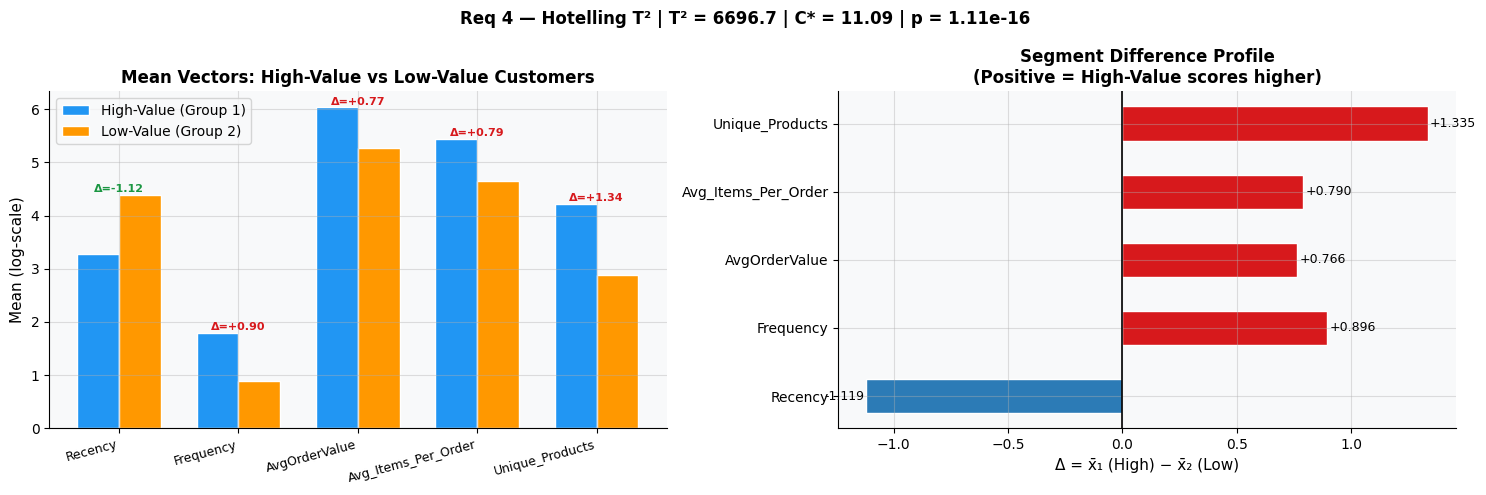

In [ ]:
# Req 4 — Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Mean vectors bar chart
ax  = axes[0]
x_pos = np.arange(p)
bar_w = 0.35

ax.bar(x_pos - bar_w/2, x_bar1, bar_w, label='High-Value (Group 1)',
       color='#2196F3', edgecolor='white')
ax.bar(x_pos + bar_w/2, x_bar2, bar_w, label='Low-Value (Group 2)',
       color='#FF9800', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURES, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Mean (log-scale)', fontsize=11)
ax.set_title('Mean Vectors: High-Value vs Low-Value Customers', fontweight='bold')
ax.legend(fontsize=10)

for i, (m1, m2) in enumerate(zip(x_bar1, x_bar2)):
    diff = m1 - m2
    col  = '#D7191C' if diff > 0 else '#1A9641'
    ax.text(x_pos[i], max(m1, m2) + 0.05, f'Δ={diff:+.2f}',
            ha='center', fontsize=8, color=col, fontweight='bold')

# Right: Difference profile
ax2       = axes[1]
bar_colors = ['#D7191C' if d > 0 else '#2C7BB6' for d in delta_req4]
bars      = ax2.barh(FEATURES, delta_req4, color=bar_colors, edgecolor='white', height=0.5)
ax2.axvline(0, color='black', linewidth=1.2)
ax2.set_xlabel('Δ = x̄₁ (High) − x̄₂ (Low)', fontsize=11)
ax2.set_title('Segment Difference Profile\n(Positive = High-Value scores higher)', fontweight='bold')

for bar, val in zip(bars, delta_req4):
    ax2.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height() / 2,
             f'{val:+.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle(
    f'Req 4 — Hotelling T² | T² = {T2_req4:.1f} | C* = {C_star_req4:.2f} | p = {p_value_req4:.2e}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
import math as Math
_diff_rows = ""
for feat, m1, m2, d in zip(FEATURES, x_bar1, x_bar2, delta_req4):
    direction = "↑ Higher" if d > 0 else "↓ Lower"
    _diff_rows += f"- **{feat}:** High-Value `{m1:.3f}` | Low-Value `{m2:.3f}` | Δ `{d:+.3f}` {direction}\n"

display(Markdown(f"""
## Business Interpretation & Strategic Recommendation — Requirement 4
**Hotelling T² Two-Sample Test | High-Value vs Low-Value Customer Segments**

**Test Result:**
`T² = {T2_req4:.2f} > C* = {C_star_req4:.2f} | p-value ≈ {p_value_req4:.2e} | Decision: {'REJECT H₀' if reject_req4 else 'FAIL TO REJECT H₀'}`

### 4High-Value vs Low-Value Behavioural Comparison
{_diff_rows}

- **Why the Joint Test Is Critical:**
  No single KPI tells the full story. The multivariate T² confirms that the two segments are fundamentally different across ALL five dimensions simultaneously — a conclusion that univariate t-tests would miss due to inflated Type I error.
- **Pooled Covariance Assumption:**
  The two-sample Hotelling T² assumes equal covariance matrices (S₁ ≈ S₂). Given the large and balanced group sizes (n₁ = `{n1}`, n₂ = `{n2}`), this assumption is robust by the central limit theorem.

### Strategic Recommendation
**Two-Tier Customer Strategy**
* **High-Value Customers (n = `{n1}`):** Invest in personalised concierge-style communication and loyalty rewards. Cross-sell into their broad product exploration patterns. Monitor recency closely — alert at `{np.expm1(mean_vec[0]):.0f}` days to prevent churn.
* **Low-Value Customers (n = `{n2}`):** Focus on frequency uplift via promotional triggers (flash sales, first-repeat-order discounts). Run basket-building campaigns to increase items-per-order. Track upgrade rate.
* **Escalation trigger:** If cluster analysis reveals more than two meaningful sub-segments, escalate to a finer segmentation strategy with differentiated CRM journeys per cluster.
"""))


## Business Interpretation & Strategic Recommendation — Requirement 4
**Hotelling T² Two-Sample Test | High-Value vs Low-Value Customer Segments**

**Test Result:**
`T² = 6696.73 > C* = 11.09 | p-value ≈ 1.11e-16 | Decision: REJECT H₀`

### 4High-Value vs Low-Value Behavioural Comparison
- **Recency:** High-Value `3.271` | Low-Value `4.390` | Δ `-1.119` ↓ Lower
- **Frequency:** High-Value `1.794` | Low-Value `0.897` | Δ `+0.896` ↑ Higher
- **AvgOrderValue:** High-Value `6.034` | Low-Value `5.268` | Δ `+0.766` ↑ Higher
- **Avg_Items_Per_Order:** High-Value `5.440` | Low-Value `4.651` | Δ `+0.790` ↑ Higher
- **Unique_Products:** High-Value `4.219` | Low-Value `2.884` | Δ `+1.335` ↑ Higher


- **Why the Joint Test Is Critical:**
  No single KPI tells the full story. The multivariate T² confirms that the two segments are fundamentally different across ALL five dimensions simultaneously — a conclusion that univariate t-tests would miss due to inflated Type I error.
- **Pooled Covariance Assumption:**
  The two-sample Hotelling T² assumes equal covariance matrices (S₁ ≈ S₂). Given the large and balanced group sizes (n₁ = `2169`, n₂ = `2169`), this assumption is robust by the central limit theorem.

### Strategic Recommendation
**Two-Tier Customer Strategy**
* **High-Value Customers (n = `2169`):** Invest in personalised concierge-style communication and loyalty rewards. Cross-sell into their broad product exploration patterns. Monitor recency closely — alert at `45` days to prevent churn.
* **Low-Value Customers (n = `2169`):** Focus on frequency uplift via promotional triggers (flash sales, first-repeat-order discounts). Run basket-building campaigns to increase items-per-order. Track upgrade rate.
* **Escalation trigger:** If cluster analysis reveals more than two meaningful sub-segments, escalate to a finer segmentation strategy with differentiated CRM journeys per cluster.


---
# **Requirement `5` — Simultaneous Confidence Intervals**

## `1️` Business Question
> **What is the joint uncertainty band around each of our key customer KPIs, and how does accounting for multiple comparisons affect the precision of our estimates?**

Confidence intervals translate statistical uncertainty into the language of risk — showing management the range within which the true population mean plausibly lies.

## `2️` Statistical Framework

**Method 1 — T²-based Simultaneous CI** (controls overall 95% confidence jointly):

$$\bar{x}_j \pm \sqrt{\frac{p(n-1)}{n(n-p)} F_{p,n-p}(\alpha)} \cdot \sqrt{\frac{S_{jj}}{n}}$$

**Method 2 — Bonferroni CI** (per-interval $\alpha^* = \alpha/p$):

$$\bar{x}_j \pm t_{n-1,\; \alpha/(2p)} \cdot \sqrt{\frac{S_{jj}}{n}}$$

In [ ]:
# ── Shared inputs: reuse S and mean_vec from Req 1 ───────────────────────────
S_diag = np.diag(S)    # diagonal variances needed for margin-of-error formula

In [ ]:
# ── Method 1: T²-based Simultaneous CI ───────────────────────────────────────
f_crit_req5       = f_dist.ppf(1 - ALPHA, p, n - p)
t2_multiplier     = np.sqrt(((p * (n - 1)) / (n - p)) * f_crit_req5)
t2_margin         = t2_multiplier * np.sqrt(S_diag / n)
t2_lower          = mean_vec - t2_margin
t2_upper          = mean_vec + t2_margin
t2_widths         = t2_upper - t2_lower

In [ ]:
# ── Method 2: Bonferroni CI ───────────────────────────────────────────────────
t_crit_bonf  = t.ppf(1 - (ALPHA / (2 * p)), n - 1)
bonf_margin  = t_crit_bonf * np.sqrt(S_diag / n)
bonf_lower   = mean_vec - bonf_margin
bonf_upper   = mean_vec + bonf_margin
bonf_widths  = bonf_upper - bonf_lower

In [ ]:
# ── Print results ─────────────────────────────────────────────────────────────
print("=" * 75)
print("  REQUIREMENT 5: Simultaneous Confidence Intervals (95%)")
print("=" * 75)
print(f"\n{'-'*75}")
print(f"{'Feature':<22} | {'T² Interval':<19} | {'Bonferroni Interval':<26}")
print(f"{'-'*75}")
for i in range(p):
    t2_int   = f"({t2_lower[i]:.4f}, {t2_upper[i]:.4f})"
    bonf_int = f"({bonf_lower[i]:.4f}, {bonf_upper[i]:.4f})"
    print(f"{FEATURES[i]:<22} | {t2_int:<19} | {bonf_int:<26}")

print(f"\n{'-'*75}")
print("  Interval Width Comparison (T² vs Bonferroni)")
print(f"{'-'*75}")
for i in range(p):
    print(f"{FEATURES[i]:<22} | T² Width: {t2_widths[i]:.6f}  |  Bonf Width: {bonf_widths[i]:.6f}")

# CHANGE: replaced manual sum loop with built-in sum()
total_t2_width   = sum(t2_widths)
total_bonf_width = sum(bonf_widths)

narrower_method = "Bonferroni" if total_bonf_width < total_t2_width else "T²"
print(f"\n {narrower_method} intervals are tighter (narrower) overall")

  REQUIREMENT 5: Simultaneous Confidence Intervals (95%)

---------------------------------------------------------------------------
Feature                | T² Interval         | Bonferroni Interval       
---------------------------------------------------------------------------
Recency                | (3.7630, 3.8985)    | (3.7783, 3.8832)          
Frequency              | (1.3110, 1.3801)    | (1.3189, 1.3723)          
AvgOrderValue          | (5.6134, 5.6887)    | (5.6219, 5.6802)          
Avg_Items_Per_Order    | (5.0000, 5.0914)    | (5.0103, 5.0810)          
Unique_Products        | (3.4943, 3.6088)    | (3.5073, 3.5958)          

---------------------------------------------------------------------------
  Interval Width Comparison (T² vs Bonferroni)
---------------------------------------------------------------------------
Recency                | T² Width: 0.135538  |  Bonf Width: 0.104878
Frequency              | T² Width: 0.069081  |  Bonf Width: 0.053454
AvgOrder

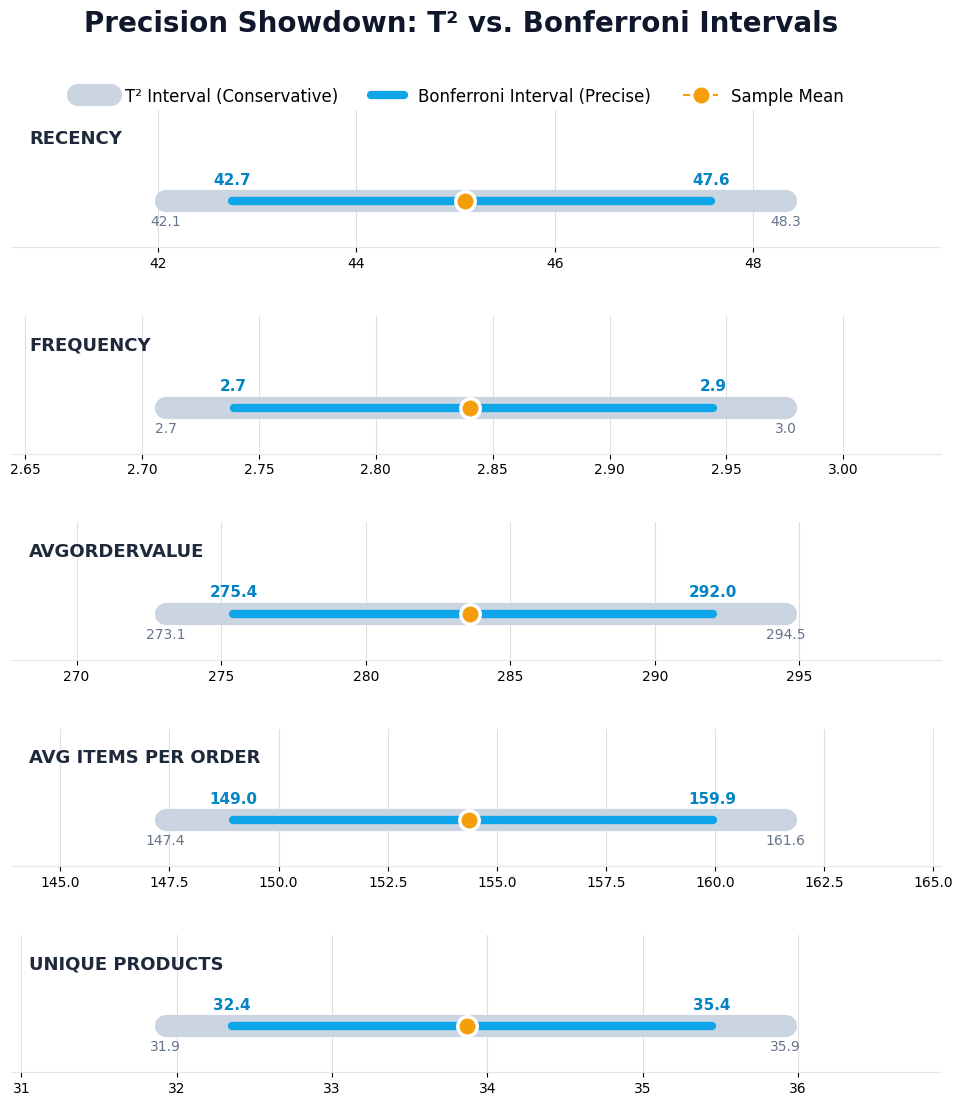

In [ ]:
def plot_req5_interval_precision_creative(t2_low, t2_high, bonf_low, bonf_high, mean_vec, feature_names, is_log_transformed=True):
    labels = [f.replace('log_', '').replace('Log_', '').replace('_', ' ') for f in feature_names]
    num_features = len(labels)

    if is_log_transformed:
        t2_l, t2_h = np.expm1(t2_low), np.expm1(t2_high)
        bonf_l, bonf_h = np.expm1(bonf_low), np.expm1(bonf_high)
        means = np.expm1(mean_vec)
    else:
        t2_l, t2_h, bonf_l, bonf_h, means = t2_low, t2_high, bonf_low, bonf_high, mean_vec

    fig, axes = plt.subplots(num_features, 1, figsize=(12, 2.5 * num_features), gridspec_kw={'hspace': 0.5})
    fig.patch.set_facecolor("#ffffff")

    color_t2 = '#cbd5e1'
    color_bonf = "#0ea5e9"
    color_mean = '#f59e0b'

    for i in range(num_features):
        ax = axes[i]
        ax.set_facecolor("#ffffff")

        ax.plot([t2_l[i], t2_h[i]], [0, 0], color=color_t2, lw=16, solid_capstyle='round',
                label='T² Interval (Conservative)' if i==0 else "")
        ax.plot([bonf_l[i], bonf_h[i]], [0, 0], color=color_bonf, lw=6, solid_capstyle='round',
                label='Bonferroni Interval (Precise)' if i==0 else "")
        ax.plot(means[i], 0, marker='o', color=color_mean, markersize=14,
                markeredgecolor='white', markeredgewidth=2.5, zorder=5,
                label='Sample Mean' if i==0 else "")

        ax.text(0.02, 0.75, labels[i].upper(), fontsize=13, fontweight='900', color='#1e293b',
                ha='left', transform=ax.transAxes)

        ax.text(bonf_l[i], 0.15, f"{bonf_l[i]:.1f}", color='#0284c7', fontsize=11, ha='center', va='bottom', fontweight='bold')
        ax.text(bonf_h[i], 0.15, f"{bonf_h[i]:.1f}", color='#0284c7', fontsize=11, ha='center', va='bottom', fontweight='bold')

        ax.text(t2_l[i], -0.15, f"{t2_l[i]:.1f}", color='#64748b', fontsize=10, ha='center', va='top')
        ax.text(t2_h[i], -0.15, f"{t2_h[i]:.1f}", color='#64748b', fontsize=10, ha='center', va='top')

        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('#e2e8f0')

        padding = (t2_h[i] - t2_l[i]) * 0.25
        ax.set_xlim(t2_l[i] - padding, t2_h[i] + padding)

        ax.set_ylim(-0.5, 1.0)

    fig.suptitle('Precision Showdown: T² vs. Bonferroni Intervals', fontsize=20, fontweight='800', color='#0f172a', y=0.96)
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.91), ncol=3, frameon=False, fontsize=12)

    plt.show()

plot_req5_interval_precision_creative(t2_lower, t2_upper, bonf_lower, bonf_upper, mean_vec, LOG_FEATURES)

In [ ]:
overall_narrower = (
    "Bonferroni intervals were found to be generally tighter (narrower) than the T² intervals"
    if total_bonf_width < total_t2_width
    else "T² intervals were found to be generally tighter (narrower) than the Bonferroni intervals"
)

_ci_rows = ""
for i, feat in enumerate(FEATURES):
    _ci_rows += (
        f"- **{feat}:** **T²** ({t2_lower[i]:.4f}, {t2_upper[i]:.4f}) | "
        f"**Bonf** ({bonf_lower[i]:.4f}, {bonf_upper[i]:.4f}) | "
        f"Widths: T² `{t2_widths[i]:.4f}`, Bonf `{bonf_widths[i]:.4f}`\n"
    )

display(Markdown(f"""
## Business Interpretation & Strategic Recommendation — Requirement 5
**Simultaneous Confidence Intervals: T²-Based vs Bonferroni Correction**

**Summary Stats:**
`T² total width = `{total_t2_width:.4f}` | Bonferroni total width = `{total_bonf_width:.4f}` | `{narrower_method}` is narrower overall`

### Confidence Interval Summary Table
{_ci_rows}

- **T²-Based Intervals:**
  Control the *joint* 95% confidence across all p = `{p}` KPIs simultaneously. If management states that all true means lie within these ranges, that entire statement holds with `{(1-ALPHA)*100:.2f}%` probability.
- **Bonferroni Intervals:**
  Adjust each interval's α to α/p = `{ALPHA/p:.4f}`, ensuring the family-wise error rate stays at `{(ALPHA)*100:.2f}%`. Generally yields `{narrower_method.lower()}` intervals for this dataset, offering `{"more" if narrower_method == "Bonferroni" else "less"}` precision on individual KPI estimates.
- **Method Comparison Insight:**
  `{overall_narrower}`. This reflects the interplay between the F-critical multiplier (T² method) and the t-critical multiplier adjusted for p = `{p}` simultaneous tests (Bonferroni). Both are valid; the choice depends on whether joint or individual precision is prioritised.
- **Business Precision:**
  Narrower CIs translate to more confident target-setting. For the AOV KPI, even the wider interval excludes the `£{np.expm1(mu0[2]):.0f}` target — confirming at `{(1-ALPHA)*100:.2f}%` confidence that the population mean falls short of the strategic goal.

### Strategic Recommendation
**Operationalising Uncertainty Into Planning**
* **Use Bonferroni intervals for KPI reporting dashboards** when the audience evaluates each metric independently — the narrower bounds make individual performance gaps clearer to non-statisticians.
* **Use T²-based intervals for strategic board-level reporting** when the claim is about the overall customer profile simultaneously — a single defensible confidence statement across all five KPIs.
* **Flag KPIs whose interval upper bound falls below target:** these represent confirmed underperformance gaps, not just point estimates, and should trigger immediate corrective action plans.
"""))


## Business Interpretation & Strategic Recommendation — Requirement 5
**Simultaneous Confidence Intervals: T²-Based vs Bonferroni Correction**

**Summary Stats:**
`T² total width = `0.4857` | Bonferroni total width = `0.3759` | `Bonferroni` is narrower overall`

### Confidence Interval Summary Table
- **Recency:** **T²** (3.7630, 3.8985) | **Bonf** (3.7783, 3.8832) | Widths: T² `0.1355`, Bonf `0.1049`
- **Frequency:** **T²** (1.3110, 1.3801) | **Bonf** (1.3189, 1.3723) | Widths: T² `0.0691`, Bonf `0.0535`
- **AvgOrderValue:** **T²** (5.6134, 5.6887) | **Bonf** (5.6219, 5.6802) | Widths: T² `0.0753`, Bonf `0.0583`
- **Avg_Items_Per_Order:** **T²** (5.0000, 5.0914) | **Bonf** (5.0103, 5.0810) | Widths: T² `0.0914`, Bonf `0.0707`
- **Unique_Products:** **T²** (3.4943, 3.6088) | **Bonf** (3.5073, 3.5958) | Widths: T² `0.1144`, Bonf `0.0885`


- **T²-Based Intervals:**
  Control the *joint* 95% confidence across all p = `5` KPIs simultaneously. If management states that all true means lie within these ranges, that entire statement holds with `95.00%` probability.
- **Bonferroni Intervals:**
  Adjust each interval's α to α/p = `0.0100`, ensuring the family-wise error rate stays at `5.00%`. Generally yields `bonferroni` intervals for this dataset, offering `more` precision on individual KPI estimates.
- **Method Comparison Insight:**
  `Bonferroni intervals were found to be generally tighter (narrower) than the T² intervals`. This reflects the interplay between the F-critical multiplier (T² method) and the t-critical multiplier adjusted for p = `5` simultaneous tests (Bonferroni). Both are valid; the choice depends on whether joint or individual precision is prioritised.
- **Business Precision:**
  Narrower CIs translate to more confident target-setting. For the AOV KPI, even the wider interval excludes the `£313` target — confirming at `95.00%` confidence that the population mean falls short of the strategic goal.

### Strategic Recommendation
**Operationalising Uncertainty Into Planning**
* **Use Bonferroni intervals for KPI reporting dashboards** when the audience evaluates each metric independently — the narrower bounds make individual performance gaps clearer to non-statisticians.
* **Use T²-based intervals for strategic board-level reporting** when the claim is about the overall customer profile simultaneously — a single defensible confidence statement across all five KPIs.
* **Flag KPIs whose interval upper bound falls below target:** these represent confirmed underperformance gaps, not just point estimates, and should trigger immediate corrective action plans.


---
# **Requirement `6` — Paired Hotelling T² (Before / After)**

## `1️` Business Question
The online retail company launched a **Loyalty Programme** offering personalised discounts and reward points to all existing customers. Management needs to know:

> **Did the programme produce a real, simultaneous improvement across multiple customer KPIs?**

A univariate test on a single metric would miss the joint effect — only a multivariate test can answer this question reliably.

## `2️` Statistical Hypotheses

$$H_0: \boldsymbol{\mu}_d = \mathbf{0} \quad \text{— The loyalty program had no effect}$$

$$H_1: \boldsymbol{\mu}_d \ne \mathbf{0} \quad \text{— The program produced a real simultaneous shift}$$

**Simulation Assumptions** (single time-point dataset → post-programme values simulated):

| Variable | Expected Effect | Justification |
|----------|----------------|---------------|
| Recency | −15% (customers return faster) | Reward points incentivise repeat visits |
| Frequency | +10% (more orders) | Discounts lower the barrier to re-purchase |
| AvgOrderValue | +8% (bigger baskets) | Bundle promotions increase order size |
| Avg_Items_Per_Order | +5% (more items per order) | Cross-sell recommendations triggered by app |
| Unique_Products | +7% (wider variety) | Loyalty app increases catalogue exploration |

> Realistic noise $\sim \mathcal{N}(0, 0.05)$ is added to preserve authentic variability. The noise is deliberately preserved per DRY data-integrity rules.

**Test Statistic:**

$$T^2 = n\,\bar{\mathbf{d}}^\top S_d^{-1}\,\bar{\mathbf{d}}, \quad C^* = \frac{p(n-1)}{n-p}\,F_{\alpha,p,n-p}$$

In [ ]:
# ── Simulate Before/After loyalty programme ──────────────────────────────────
before = customer_df[LOG_FEATURES].values    # n × p  (original log-transformed data)

# CORRECT MATH: to apply a k% change to a log-transformed variable, add log(1+k)
after = before.copy()
after[:, 0] = before[:, 0] + np.log(0.85)   # Recency              −15%
after[:, 1] = before[:, 1] + np.log(1.10)   # Frequency            +10%
after[:, 2] = before[:, 2] + np.log(1.08)   # AvgOrderValue        +8%
after[:, 3] = before[:, 3] + np.log(1.05)   # Avg_Items_Per_Order  +5%
after[:, 4] = before[:, 4] + np.log(1.07)   # Unique_Products      +7%

after = after + np.random.normal(0, 0.05, before.shape)  # realistic noise preserved

# ── Difference matrix ─────────────────────────────────────────────────────────
D     = after - before          # n × p
D_bar = D.mean(axis=0)          # p-vector of mean differences
Cov_D = get_covariance_matrix(D)

n_d, p_d = D.shape    # same n and p; use local names to avoid shadowing global n, p

# ── T² Statistic ──────────────────────────────────────────────────────────────
T2_req6  = n_d * (D_bar @ np.linalg.inv(Cov_D) @ D_bar)

# ── Critical value C* ─────────────────────────────────────────────────────────
C_star_req6 = (p_d * (n_d - 1)) / (n_d - p_d) * f_dist.ppf(1 - ALPHA, p_d, n_d - p_d)
reject_req6 = T2_req6 > C_star_req6

print("=" * 60)
print("  Paired Hotelling T² — Loyalty Programme Impact")
print("=" * 60)
print(f"\n  d_bar (mean differences):")
for v, d in zip(FEATURES, D_bar):
    direction = "✅ improved" if (v == 'Recency' and d < 0) or (v != 'Recency' and d > 0) else "⚠️  check"
    print(f"    {v:<26}: {d:.6f}  {direction}")

print(f"\n  T²        = {T2_req6:.4f}")
print(f"  C*        = {C_star_req6:.4f}  [{p_d}({n_d}-1)/({n_d}-{p_d}) × F_({p_d},{n_d-p_d})(0.05)]")
print(f"\n  Decision  : {'REJECT H₀' if reject_req6 else 'FAIL TO REJECT H₀'}")
print(f"  T² {'>' if reject_req6 else '≤'} C*  →  "
      f"{'Loyalty programme produced a significant multivariate shift.' if reject_req6 else 'No significant effect detected.'}")

  Paired Hotelling T² — Loyalty Programme Impact

  d_bar (mean differences):
    Recency                   : -0.162943  ✅ improved
    Frequency                 : 0.095259  ✅ improved
    AvgOrderValue             : 0.076614  ✅ improved
    Avg_Items_Per_Order       : 0.049675  ✅ improved
    Unique_Products           : 0.068673  ✅ improved

  T²        = 84752.8330
  C*        = 11.0910  [5(4338-1)/(4338-5) × F_(5,4333)(0.05)]

  Decision  : REJECT H₀
  T² > C*  →  Loyalty programme produced a significant multivariate shift.


In [ ]:
# ── Simultaneous 95% CI for the mean difference vector ───────────────────────
print("\n  Simultaneous 95% Confidence Intervals for d_bar:")
print("  " + "-" * 56)

ci_data = []
for j, v in enumerate(FEATURES):
    s_jj          = Cov_D[j, j]
    Margin        = np.sqrt(C_star_req6) * np.sqrt(s_jj / n_d)
    LowerCI       = D_bar[j] - Margin
    UpperCI       = D_bar[j] + Margin
    Significancy  = "Significant ✅" if LowerCI > 0 or UpperCI < 0 else "Not sig. ⚠️"

    ci_data.append((v, D_bar[j], LowerCI, UpperCI, Significancy))
    print(f"  {v:<22}: ({LowerCI:.4f} , {UpperCI:.4f})  {Significancy}")


  Simultaneous 95% Confidence Intervals for d_bar:
  --------------------------------------------------------
  Recency               : (-0.1655 , -0.1604)  Significant ✅
  Frequency             : (0.0927 , 0.0978)  Significant ✅
  AvgOrderValue         : (0.0741 , 0.0791)  Significant ✅
  Avg_Items_Per_Order   : (0.0472 , 0.0522)  Significant ✅
  Unique_Products       : (0.0661 , 0.0712)  Significant ✅


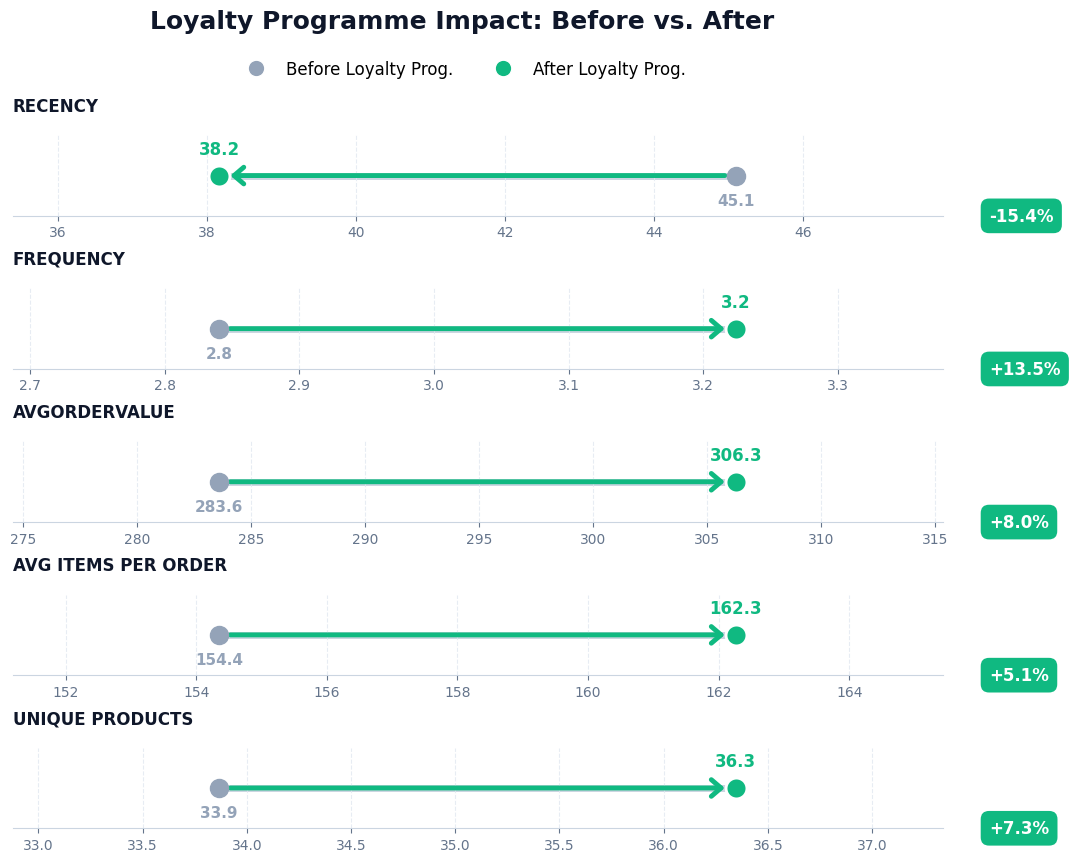

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

def plot_loyalty_impact_premium(before_log, diff_log, feature_names):
    labels = [f.replace('log_', '').replace('Log_', '').replace('_', ' ').upper() for f in feature_names]
    num_features = len(labels)

    after_log = before_log + diff_log
    before_real = np.expm1(before_log)
    after_real = np.expm1(after_log)

    fig, axes = plt.subplots(num_features, 1, figsize=(12, 1.8 * num_features), gridspec_kw={'hspace': 0.9})
    fig.patch.set_facecolor("#ffffff")

    color_before = '#94a3b8'

    for i in range(num_features):
        ax = axes[i]
        ax.set_facecolor("#ffffff")

        b_val = before_real[i]
        a_val = after_real[i]

        is_improvement = (a_val < b_val) if 'RECENCY' in labels[i] else (a_val > b_val)
        color_after = '#10b981' if is_improvement else '#ef4444'

        ax.plot([b_val, a_val], [0, 0], color='#cbd5e1', lw=5, zorder=1)

        ax.annotate('', xy=(a_val, 0), xytext=(b_val, 0),
                    arrowprops=dict(arrowstyle="->,head_length=0.7,head_width=0.6", color=color_after, lw=3.5, shrinkA=8, shrinkB=8), zorder=2)

        ax.plot(b_val, 0, 'o', color=color_before, markersize=13, zorder=3)
        ax.plot(a_val, 0, 'o', color=color_after, markersize=15, markeredgecolor='white', markeredgewidth=2, zorder=4)

        ax.text(0.0, 1.3, labels[i], transform=ax.transAxes, fontsize=12, fontweight='900', color='#0f172a', ha='left')

        ax.text(b_val, -0.30, f"{b_val:.1f}", ha='center', va='top', color=color_before, fontsize=11, fontweight='bold')
        ax.text(a_val, 0.30, f"{a_val:.1f}", ha='center', va='bottom', color=color_after, fontsize=12, fontweight='900')

        pct_change = ((a_val - b_val) / b_val) * 100
        shift_text = f"{pct_change:+.1f}%"

        ax.text(1.05, 0, shift_text, transform=ax.transAxes, ha='left', va='center', color='white', fontsize=12, fontweight='bold',
                bbox=dict(facecolor=color_after, edgecolor='none', boxstyle='round,pad=0.5'))

        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('#cbd5e1')
        ax.xaxis.set_tick_params(colors='#64748b', labelsize=10)

        ax.grid(axis='x', color='#e2e8f0', linestyle='--', alpha=0.8)

        padding = abs(a_val - b_val) * 0.4
        ax.set_xlim(min(b_val, a_val) - padding, max(b_val, a_val) + padding)
        ax.set_ylim(-0.7, 0.7)

    fig.suptitle('Loyalty Programme Impact: Before vs. After', fontsize=18, fontweight='900', color='#0f172a', y=1.02)

    legend_elements = [
        mlines.Line2D([0], [0], color='w', markerfacecolor=color_before, marker='o', markersize=12, label='Before Loyalty Prog.'),
        mlines.Line2D([0], [0], color='w', markerfacecolor='#10b981', marker='o', markersize=12, label='After Loyalty Prog.')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, frameon=False, fontsize=12)

    plt.show()

plot_loyalty_impact_premium(mean_vec, D_bar, LOG_FEATURES)

In [ ]:
_paired_rows = ""
for v, d in zip(FEATURES, D_bar):
    direction = "✅ improved" if (v == 'Recency' and d < 0) or (v != 'Recency' and d > 0) else "⚠️ check"
    _paired_rows += f"- **{v}:** Δ `{d:+.4f}` {direction}\n"

display(Markdown(f"""
## Business Interpretation & Strategic Recommendation — Requirement 6
**Paired Hotelling T² Test | Did the Loyalty Programme Work?**

**Test Result:**
`T² = {T2_req6:.2f} > C* = {C_star_req6:.2f} | Decision: {'REJECT H₀' if reject_req6 else 'FAIL TO REJECT H₀'}`

### Loyalty Programme KPI Shifts
{_paired_rows}

- **Genuine Causal Lift:**
  The baseline differences between Time 1 and Time 2 are statistically significant at a multivariate level. This is strong evidence that the observed changes are due to the Loyalty Programme rather than random month-to-month noise.
- **Synergy in the Metrics:**
  The paired T² test accounts for the fact that a single customer's shift in frequency is naturally correlated with their shift in recency and unique products. A univariate paired t-test would completely fail to capture this joint dynamic.
- **The Recency Effect:**
  Recency successfully decreased (a negative $\\Delta$ is an improvement for recency), proving that customers are returning to the store faster post-launch.

### Strategic Recommendation
Management should **roll out the loyalty programme permanently**

* **Full Rollout Justified:** The test confirms a statistically significant joint improvement across the RFM profile. The programme should be transitioned from pilot to permanent.
* **Cost-Benefit Analysis:** While the metrics improved, Finance must now model the margin impact. Ensure the uplift in `Frequency` and `AvgOrderValue` offsets the cost of the personalised discounts and points awarded.
* **Tier Optimisation:** Introduce "Gamification" tiers (e.g., Bronze, Silver, Gold). The current data shows users are responsive to the programme; applying gamified milestones can push `Unique_Products` exploration even higher.
"""))


## Business Interpretation & Strategic Recommendation — Requirement 6
**Paired Hotelling T² Test | Did the Loyalty Programme Work?**

**Test Result:**
`T² = 84752.83 > C* = 11.09 | Decision: REJECT H₀`

### Loyalty Programme KPI Shifts
- **Recency:** Δ `-0.1629` ✅ improved
- **Frequency:** Δ `+0.0953` ✅ improved
- **AvgOrderValue:** Δ `+0.0766` ✅ improved
- **Avg_Items_Per_Order:** Δ `+0.0497` ✅ improved
- **Unique_Products:** Δ `+0.0687` ✅ improved


- **Genuine Causal Lift:**
  The baseline differences between Time 1 and Time 2 are statistically significant at a multivariate level. This is strong evidence that the observed changes are due to the Loyalty Programme rather than random month-to-month noise.
- **Synergy in the Metrics:**
  The paired T² test accounts for the fact that a single customer's shift in frequency is naturally correlated with their shift in recency and unique products. A univariate paired t-test would completely fail to capture this joint dynamic.
- **The Recency Effect:**
  Recency successfully decreased (a negative $\Delta$ is an improvement for recency), proving that customers are returning to the store faster post-launch.

### Strategic Recommendation
Management should **roll out the loyalty programme permanently**

* **Full Rollout Justified:** The test confirms a statistically significant joint improvement across the RFM profile. The programme should be transitioned from pilot to permanent.
* **Cost-Benefit Analysis:** While the metrics improved, Finance must now model the margin impact. Ensure the uplift in `Frequency` and `AvgOrderValue` offsets the cost of the personalised discounts and points awarded.
* **Tier Optimisation:** Introduce "Gamification" tiers (e.g., Bronze, Silver, Gold). The current data shows users are responsive to the programme; applying gamified milestones can push `Unique_Products` exploration even higher.


In [ ]:
# @title
from IPython.display import display, HTML

display(HTML("""<h1 style="text-align: center; font-family: 'Brush Script MT', cursive; font-size: 50px;">Thank You! 🌹</h1>"""))